<h1 style="color:orange">Tutorial Network 1</h1>

Aqui presentamos un tutorial para resolver tres distintos tipos de problemas con la bilbioteca networkx, los problemas a resolver son:
<ol style="list-style-type: lower-alpha; color: orange">
  <li><span style="color: black; font-style: italic">Árbol de Mínima Expansión</span></li>
  <li><span style="color: black; font-style: italic">Ruta más corta</span></li>
  <li><span style="color: black; font-style: italic">Flujo Máximo</span></li>
</ol>

Primero haremos los pasos generales, es decir los que se va a necesitar en todos los problemas y luego especificaremos los pasos necesarios particulares para cada problema.

In [1]:
import networkx as nx #importamos las librerias necesarias para resolver y graficar los problemas
import matplotlib.pyplot as plt

<h2 style="color: #1F3A5F; font-family: Georgia"><span style="color: orange">a.</span> Árbol de Mínima Expansión</h2>

<p style="font-family: Verdana; color: #333333">
  Debido a que el método de Árbol de Mínima Expansión trabaja con <b>redes no dirigidas</b>, hay que transformar la red dirigida que tenemos en una no dirigida. En el caso de los pares de nodos que estaban unidos por dos arcos, <b>se conservó el de menor peso</b> (debido al objetivo del método, explicado a continuación). La red queda de la siguiente manera:
</p>

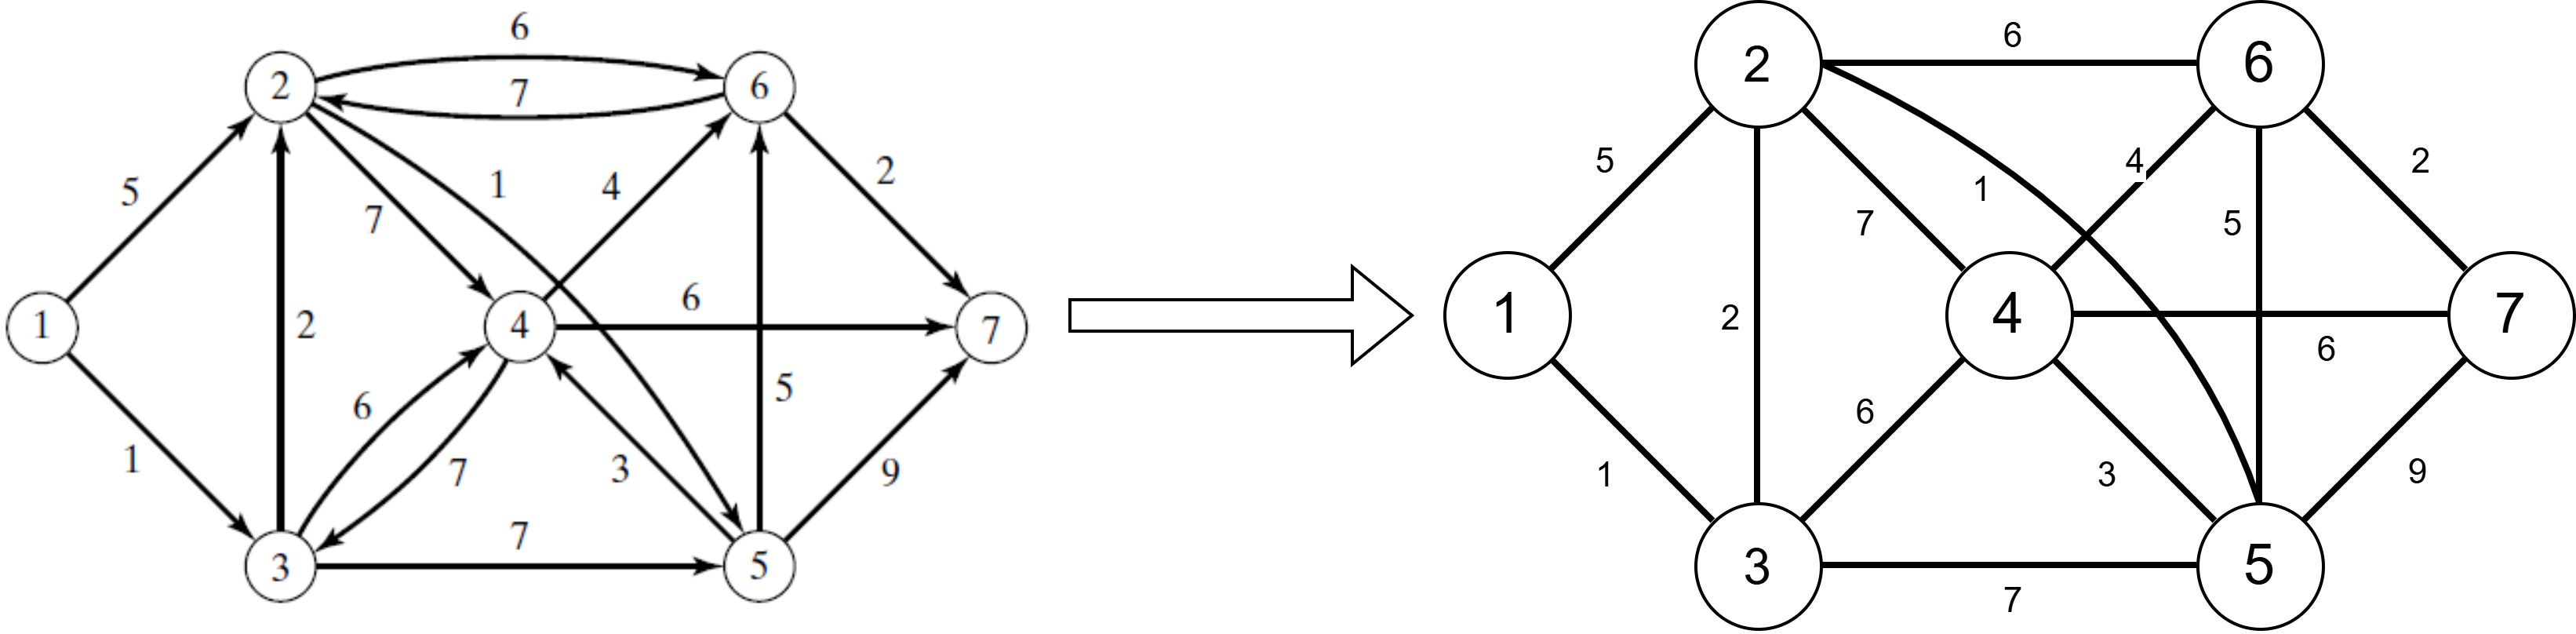

<p style="font-family: Verdana; color: #333333">
  <b style="color: #2A9D8F">Objetivo:</b> Encontrar el conjunto de arcos que <b>conecta todos los nodos</b> de la red con el <b>menor peso total posible</b>, sin formar ciclos.
</p>

<p style="font-family: Verdana; color: #333333">
  Para lograr esto, <b style="color: #6A4C93">definimos dos conjuntos:</b>
</p>

$$C_k = \{\text{Conjunto de nodos conectados de forma permanente en la iteración } k\}$$

$$\bar{C}_k = \{\text{Conjunto de nodos que aún se deben conectar de forma permanente}\}$$

<p style="font-family: Verdana; color: #333333">
  Para nuestro ejemplo, en el paso $k = 0$ nuestros conjuntos tienen los siguientes elementos:
</p>

$$C_0 = \emptyset \qquad \bar{C}_0 = \{1, 2, 3, 4, 5, 6, 7\}$$

<h3 style="font-family: Georgia; color: #1F3A5F">Paso 1</h3>

<p style="font-family: Verdana; color: #333333">
  En este paso hay que escoger cualquier nodo del conjunto $\bar{C}_0$ y pasarlo al conjunto $C_1$, el cual representará el nodo con el que vamos a comenzar. El conjunto $\bar{C}_1$ queda con los nodos restantes. Llevando esto a nuestro ejemplo, el nodo que escogemos es el 4, entonces los conjuntos quedan de la siguiente manera:
</p>

$$C_1 = \{4\} \qquad \bar{C}_1 = \{1, 2, 3, 5, 6, 7\}$$

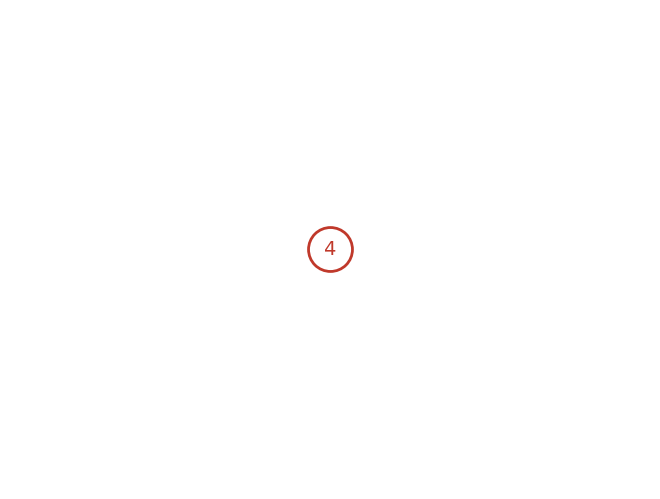

In [2]:
red = nx.Graph() #Declaramos a la variable red como un grafo vacio
red.add_node(4)  #A ese grafo le añadimos el nodo que escogimos
pos = {1: (0, 0), 2: (1, 1), 3: (1, -1), 4: (2, 0),
       5: (3, -1), 6: (3, 1), 7: (4, 0)}    #Con la intención de mantener el orden de los nodos les asignamos una ubicación en el plano cartesiano
                                            #y asi obtener una red con la mismo ubicacion que la red original
#dibujamos el nodo que ingresamos al conjunto de los conectados
nx.draw(red, pos,
        with_labels=True,
        node_color="white",       # Establecemos el relleno del nodo en blanco
        edgecolors="#C0392B",     # Establecemos un estilo para el controno del nodo
        linewidths=2,             # Establecemos el grosor del contorno del nodo
        font_color="#C0392B",     # Le ponemos color al numero del nodo
        node_size=1000,           # Lo hacemos grande ya que por el momento es el unico nodo
        font_size=14)             # Ajustamos el tamaño del numero dentro del nodo para que se vea biene en relacioón a su tamaño
plt.show() 

<h3 style="font-family: Georgia; color: #1F3A5F">Paso 2</h3>

<p style="font-family: Verdana; color: #333333">
  En los pasos siguientes, es decir, en los pasos $k$ con $k = 2, 3, \dots$, hay que seleccionar un nodo del conjunto de nodos no conectados $\bar{C}_{k-1}$, de tal manera que genere el arco de menor peso con alguno de los nodos ya conectados en $C_{k-1}$.
</p>

<p style="font-family: Verdana; color: #333333">
  En nuestro ejemplo, de todos los nodos del conjunto $\bar{C}_1$ hay que ver cuál genera el arco de menor peso con el nodo que está en $C_1$, en este caso el 4. Este nodo tiene conexiones con $\{2, 3, 5, 6, 7\}$; sin embargo, el que produce el arco de menor peso es el 5, con un peso de 3.
</p>

<p style="font-family: Verdana; color: #333333">
  Ahora actualizamos los conjuntos: el conjunto de nodos conectados y el de nodos no conectados quedan así:
</p>

$$C_2 = \{4, 5\} \qquad \bar{C}_2 = \{1, 2, 3, 6, 7\}$$

<p style="font-family: Verdana; color: #333333">
  Hacemos la conexión y seguimos al siguiente paso.
</p>

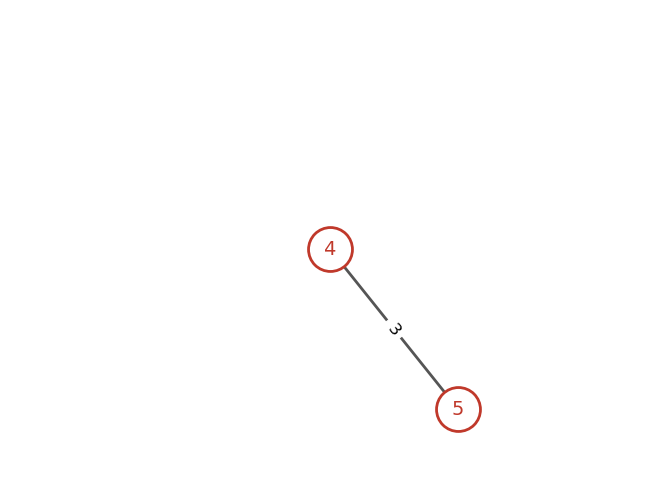

In [3]:
red.add_edge(4, 5, weight=3) #agregamos el nodo 5 a nuestra red y ademas hacemos la conexión asignandole el peso correspondiente weight=3
pesos = nx.get_edge_attributes(red, "weight") #definimos la variable pesos, la cual es un diccionario que contiene las conexiones y el peso de la conexion
nx.draw(red, pos,               #Dibujamos el grafo red usando las coordenadas establecidas en pos
        with_labels=True,       #Mostramos el nombre de cada nodo
        node_color="white",     #Relleno blanco
        edgecolors="#C0392B",   #Color del contorno
        linewidths=2,           #Grosor del contorno
        font_color="#C0392B",   #Color del numero dentro del nodo
        node_size=1000,         #Tamaño del circulo
        font_size=14,           #Tamaño del numero
        edge_color="#555555",     # Color del arco
        width=2)                  # Grosor del arco

nx.draw_networkx_edge_labels(red, pos,      #Mostramos el peso sobre los arcos de la red y en la posicions correcta
                             edge_labels=pesos,  #Toma el peso guardado en el diccionario pesos de la conexion correspondiente
                             font_color="black",   # Color del numero que representa el peso
                             font_size=12)        #Tamaño de los pesos

plt.xlim(-0.5, 4.5)     #Fijamos el area viseble del dibujo de tal manera que tengamos el mismo encuadre siempre
plt.ylim(-1.5, 1.5)
plt.show()

<h3 style="font-family: Georgia; color: #1F3A5F">Paso 3</h3>

<p style="font-family: Verdana; color: #333333">
    Seguimos con la misma lógica: vemos qué nodos del conjunto $\bar{C}_2$ están conectados a los nodos de $C_2$ y, además, producen el arco más corto.
</p>

<p style="font-family: Verdana; color: #333333">
    El nodo 4 está conectado a $\{2, 3, 6, 7\}$ con pesos 7, 6, 4 y 6, y el nodo 5 está conectado a $\{2, 3, 6, 7\}$ con pesos 1, 7, 5 y 9. El que produce el arco más corto es la conexión $(5, 2)$, con un peso de 1.
</p>

<p style="font-family: Verdana; color: #333333">
    Actualizamos los conjuntos para el paso siguiente; únicamente pasamos el nodo seleccionado del conjunto de nodos no conectados al de nodos conectados:
</p>

$$C_3 = \{2, 4, 5\} \qquad \bar{C}_3 = \{1, 3, 6, 7\}$$

<p style="font-family: Verdana; color: #333333">
    Dibujamos la red con la nueva conexión y su peso, y pasamos al paso siguiente.
</p>

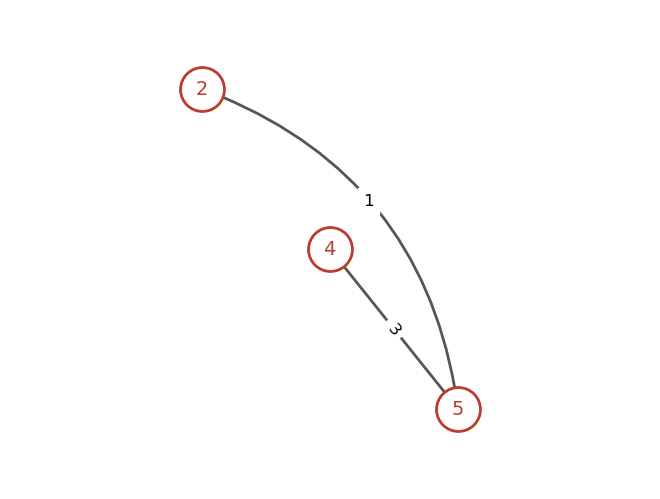

In [4]:
red.add_edge(5,2,weight=1)    #a la red le agregamos la conexión (5,2) y ademas el peso del arco
pesos = nx.get_edge_attributes(red, "weight") #volvemos a calcular el diccionario el cual extrae los arcos y los pesos correspondientes a cada conexion
# En este paso ocupmos una curbatura para mostrarlo tal cual la red original, etonces dibujamos la red en dos pasos:
#Primero los arcos que no ocupan curva
rectos = []                       # Generamos lista vacia para los arcos que no ocupan curva
for arco in red.edges:            # En la red vamos a recorrer cada arco
    if set(arco) != {2, 5}:       # si no es el arco 5–2
        rectos.append(arco)       # lo agrega a la lista
nx.draw(red, pos,       #Dibujamos primero los arcos sin curvatura
        edgelist=rectos,          # Estos arcos los extraemos de la lista rectos
        with_labels=True,         #Nombre de cada nodo
        node_color="white",       #Relleno del nodo
        edgecolors="#C0392B",     #Color del contorno
        linewidths=2,             #Grosor del contorno
        font_color="#C0392B",     #Color del numero dentro del nodo
        node_size=1000,           #Tamaño del nodo
        font_size=14,             #Tamaño del numero dentro del nodo
        edge_color="#555555",     #Color del arco
        width=2)                  #Grosor del arco

#Ahora dibujamos el arco que ocupa curvatura
nx.draw_networkx_edges(red, pos,               
                       edgelist=[(5, 2)],    #Le decimos que dibuje unicamente el arco curvo
                       connectionstyle="arc3,rad=0.3",   # La curvatura
                       arrows=True, arrowstyle="-",      # Jypeter solo curva arcos con flecha, al poner - le quitamos la punta de la flecha
                       edge_color="#555555",             #Color del arco
                       width=2,                          # Grosor del arco
                       node_size=1000)                   #Tamaño del nodo

# Pesos de los arcos rectos
pesos_rectos = {arco: p for arco, p in pesos.items() if set(arco) != {2, 5}} #Generamos una lista la cual extrae del diccionario pesos las conexiones(arco) y el peso (p) separandolos para guardarlos
#en la lista pero solo los arcos distintos a {2,5}
nx.draw_networkx_edge_labels(red, pos, edge_labels=pesos_rectos,
                             font_color="black", font_size=12)    #Dibuja los pesos de los arcos rectos

# Peso del arco curvo, colocado de manera especifica
plt.text(2.3, 0.3, "1", color="black", fontsize=12,
         ha="center", va="center", backgroundcolor="white")
plt.xlim(-0.5, 4.5)
plt.ylim(-1.5, 1.5)   #Ponemos el encuadre de siempre
plt.show()

<h3 style="font-family: Georgia; color: #1F3A5F">Paso 4</h3>

<p style="font-family: Verdana; color: #333333">
    Repetimos el proceso del paso anterior: buscamos los nodos del conjunto $\bar{C}_3$ que estén conectados a los nodos del conjunto $C_3$ y, además, produzcan el arco con menor peso.
</p>

<ul style="font-family: Verdana; color: #333333">
    <li>El nodo 4 está conectado a $\{3, 6, 7\}$; para este nodo, la conexión de menor peso es $(4, 6)$, con peso 4.</li>
    <li>El nodo 5 está conectado a $\{3, 6, 7\}$; en este nodo, la conexión de menor peso es $(5, 6)$, con peso 5.</li>
    <li>Finalmente, el nodo 2 está conectado a $\{1, 3, 6\}$; en este nodo, la conexión de menor peso es $(2, 3)$, con peso 2.</li>
</ul>

<p style="font-family: Verdana; color: #333333">
    Entre los candidatos escogemos la conexión con el menor peso, que es $(2, 3)$ con peso 2, y actualizamos los conjuntos:
</p>

$$C_4 = \{2, 3, 4, 5\} \qquad \bar{C}_4 = \{1, 6, 7\}$$

<p style="font-family: Verdana; color: #333333">
    <b>Nota:</b> en cada paso se revisan todas las conexiones entre el conjunto de nodos conectados y el de no conectados, y se elige la de menor peso. Es decir, cada nodo del conjunto de conectados puede tener conexiones con nodos del conjunto de no conectados, y hay que analizar cada una de ellas para escoger la de menor peso. Lo aclaro aquí porque en los pasos siguientes se omitirán algunos de estos detalles para agilizar el proceso.
</p>

<p style="font-family: Verdana; color: #333333">
    Finalmente, dibujamos la red con la nueva conexión.
</p>

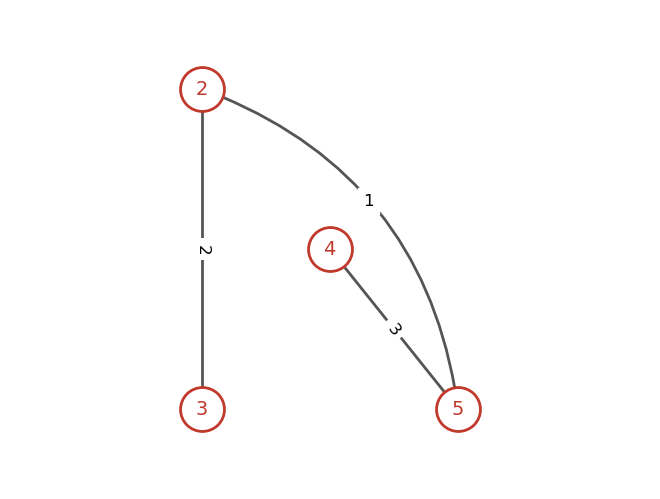

In [5]:
red.add_edge(2,3,weight=2)    #a la red le agregamos la conexión (2,3) y ademas el peso del arco
pesos = nx.get_edge_attributes(red, "weight") #volvemos a calcular el diccionario el cual extrae los conexiones y los pesos correspondientes a cada conexion
# En este paso ocupmos una curbatura para mostrarlo tal cual la red original, etonces dibujamos la red en dos pasos:
#Primero los arcos que no ocupan curva
rectos = []                       # Generamos lista vacia para los arcos que no ocupan curva
for arco in red.edges:            # En la red vamos a recorrer cada arco
    if set(arco) != {2, 5}:       # si no es el arco 5–2
        rectos.append(arco)       # lo agrega a la lista
nx.draw(red, pos,       #Dibujamos primero los arcos sin curvatura
        edgelist=rectos,          # Estos arcos los extraemos de la lista rectos
        with_labels=True,         #Nombre de cada nodo
        node_color="white",       #Relleno del nodo
        edgecolors="#C0392B",     #Color del contorno
        linewidths=2,             #Grosor del contorno
        font_color="#C0392B",     #Color del numero dentro del nodo
        node_size=1000,           #Tamaño del nodo
        font_size=14,             #Tamaño del numero dentro del nodo
        edge_color="#555555",     #Color del arco
        width=2)                  #Grosor del arco

#Ahora dibujamos el arco que ocupa curvatura
nx.draw_networkx_edges(red, pos,               
                       edgelist=[(5, 2)],    #Le decimos que dibuje unicamente el arco curvo
                       connectionstyle="arc3,rad=0.3",   # La curvatura
                       arrows=True, arrowstyle="-",      # Jypeter solo curva arcos con flecha, al poner - le quitamos la punta de la flecha
                       edge_color="#555555",             #Color del arco
                       width=2,                          # Grosor del arco
                       node_size=1000)                   #Tamaño del nodo

# Pesos de los arcos rectos
pesos_rectos = {arco: p for arco, p in pesos.items() if set(arco) != {2, 5}} #Generamos una lista la cual extrae del diccionario pesos las conexiones(arco) y el peso (p) separandolos para guardarlos
#en la lista pero solo los arcos distintos a {2,5}
nx.draw_networkx_edge_labels(red, pos, edge_labels=pesos_rectos,
                             font_color="black", font_size=12)    #Dibuja los pesos de los arcos rectos

# Peso del arco curvo, colocado de manera especifica
plt.text(2.3, 0.3, "1", color="black", fontsize=12,
         ha="center", va="center", backgroundcolor="white")
plt.xlim(-0.5, 4.5)
plt.ylim(-1.5, 1.5)   #Ponemos el encuadre de siempre
plt.show()

<h3 style="font-family: Georgia; color: #1F3A5F">Paso 5</h3>

<p style="font-family: Verdana; color: #333333">
    Analizamos las conexiones:
</p>

<ul style="font-family: Verdana; color: #333333">
    <li>El nodo 4 está conectado a $\{6, 7\}$; la conexión de menor peso es $(4, 6)$, con peso 4.</li>
    <li>El nodo 5 está conectado a $\{6, 7\}$; la conexión de menor peso es $(5, 6)$, con peso 5.</li>
    <li>El nodo 2 está conectado a $\{1, 6\}$; la conexión de menor peso es $(2, 1)$, con peso 5.</li>
    <li>El último nodo conectado es el 3, que solo tiene una posible conexión: con $\{1\}$, con peso 1.</li>
</ul>

<p style="font-family: Verdana; color: #333333">
    Así, la conexión seleccionada es $(3, 1)$, con peso 1, y actualizamos los conjuntos:
</p>

$$C_5 = \{1, 2, 3, 4, 5\} \qquad \bar{C}_5 = \{6, 7\}$$

<p style="font-family: Verdana; color: #333333">
    Dibujamos la red con la nueva conexión.
</p>

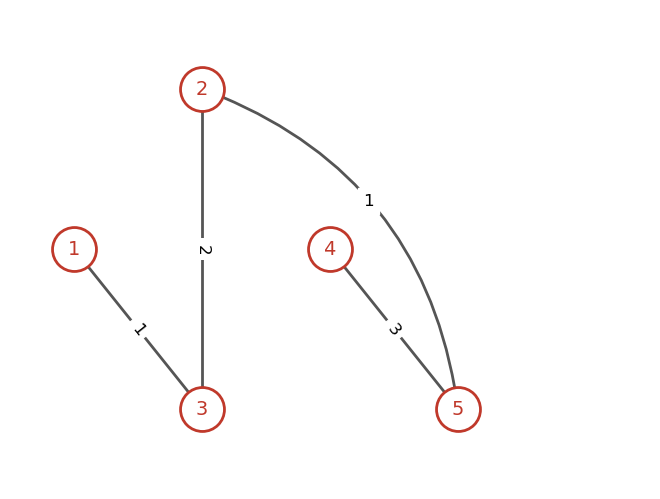

In [6]:
red.add_edge(3,1,weight=1)    #a la red le agregamos la conexión (3,1) y ademas el peso del arco
pesos = nx.get_edge_attributes(red, "weight") #volvemos a calcular el diccionario el cual extrae los conexiones y los pesos correspondientes a cada conexion
# En este paso ocupmos una curbatura para mostrarlo tal cual la red original, etonces dibujamos la red en dos pasos:
#Primero los arcos que no ocupan curva
rectos = []                       # Generamos lista vacia para los arcos que no ocupan curva
for arco in red.edges:            # En la red vamos a recorrer cada arco
    if set(arco) != {2, 5}:       # si no es el arco 5–2
        rectos.append(arco)       # lo agrega a la lista
nx.draw(red, pos,       #Dibujamos primero los arcos sin curvatura
        edgelist=rectos,          # Estos arcos los extraemos de la lista rectos
        with_labels=True,         #Nombre de cada nodo
        node_color="white",       #Relleno del nodo
        edgecolors="#C0392B",     #Color del contorno
        linewidths=2,             #Grosor del contorno
        font_color="#C0392B",     #Color del numero dentro del nodo
        node_size=1000,           #Tamaño del nodo
        font_size=14,             #Tamaño del numero dentro del nodo
        edge_color="#555555",     #Color del arco
        width=2)                  #Grosor del arco

#Ahora dibujamos el arco que ocupa curvatura
nx.draw_networkx_edges(red, pos,               
                       edgelist=[(5, 2)],    #Le decimos que dibuje unicamente el arco curvo
                       connectionstyle="arc3,rad=0.3",   # La curvatura
                       arrows=True, arrowstyle="-",      # Jypeter solo curva arcos con flecha, al poner - le quitamos la punta de la flecha
                       edge_color="#555555",             #Color del arco
                       width=2,                          # Grosor del arco
                       node_size=1000)                   #Tamaño del nodo

# Pesos de los arcos rectos
pesos_rectos = {arco: p for arco, p in pesos.items() if set(arco) != {2, 5}} #Generamos una lista la cual extrae del diccionario pesos las conexiones(arco) y el peso (p) separandolos para guardarlos
#en la lista pero solo los arcos distintos a {2,5}
nx.draw_networkx_edge_labels(red, pos, edge_labels=pesos_rectos,
                             font_color="black", font_size=12)    #Dibuja los pesos de los arcos rectos

# Peso del arco curvo, colocado de manera especifica
plt.text(2.3, 0.3, "1", color="black", fontsize=12,
         ha="center", va="center", backgroundcolor="white")
plt.xlim(-0.5, 4.5)
plt.ylim(-1.5, 1.5)   #Ponemos el encuadre de siempre
plt.show()

<h3 style="font-family: Georgia; color: #1F3A5F">Paso 6</h3>

<p style="font-family: Verdana; color: #333333">
    Analizamos las conexiones:
</p>

<ul style="font-family: Verdana; color: #333333">
    <li>El nodo 4 está conectado a $\{6, 7\}$; la conexión de menor peso es $(4, 6)$, con peso 4.</li>
    <li>El nodo 5 está conectado a $\{6, 7\}$; la conexión de menor peso es $(5, 6)$, con peso 5.</li>
    <li>El nodo 2 está conectado a $\{6\}$; la única conexión que se puede dar es $(2, 6)$, con peso 6.</li>
</ul>

<p style="font-family: Verdana; color: #333333">
    Así, la conexión seleccionada es $(4, 6)$, con peso 4, y actualizamos los conjuntos:
</p>

$$C_6 = \{1, 2, 3, 4, 5, 6\} \qquad \bar{C}_6 = \{7\}$$

<p style="font-family: Verdana; color: #333333">
    Dibujamos la red con la nueva conexión.
</p>

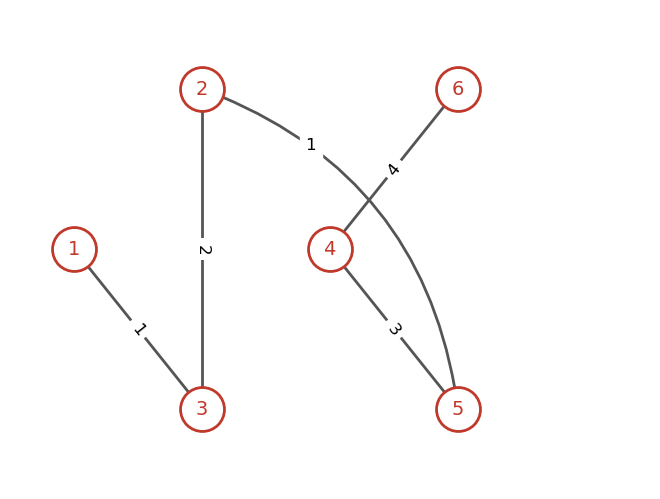

In [7]:
red.add_edge(4,6,weight=4)    #a la red le agregamos la conexión (4,6) y ademas el peso del arco
pesos = nx.get_edge_attributes(red, "weight") #volvemos a calcular el diccionario el cual extrae los conexiones y los pesos correspondientes a cada conexion
# En este paso ocupmos una curbatura para mostrarlo tal cual la red original, etonces dibujamos la red en dos pasos:
#Primero los arcos que no ocupan curva
rectos = []                       # Generamos lista vacia para los arcos que no ocupan curva
for arco in red.edges:            # En la red vamos a recorrer cada arco
    if set(arco) != {2, 5}:       # si no es el arco 5–2
        rectos.append(arco)       # lo agrega a la lista
nx.draw(red, pos,       #Dibujamos primero los arcos sin curvatura
        edgelist=rectos,          # Estos arcos los extraemos de la lista rectos
        with_labels=True,         #Nombre de cada nodo
        node_color="white",       #Relleno del nodo
        edgecolors="#C0392B",     #Color del contorno
        linewidths=2,             #Grosor del contorno
        font_color="#C0392B",     #Color del numero dentro del nodo
        node_size=1000,           #Tamaño del nodo
        font_size=14,             #Tamaño del numero dentro del nodo
        edge_color="#555555",     #Color del arco
        width=2)                  #Grosor del arco

#Ahora dibujamos el arco que ocupa curvatura
nx.draw_networkx_edges(red, pos,               
                       edgelist=[(5, 2)],    #Le decimos que dibuje unicamente el arco curvo
                       connectionstyle="arc3,rad=0.3",   # La curvatura
                       arrows=True, arrowstyle="-",      # Jypeter solo curva arcos con flecha, al poner - le quitamos la punta de la flecha
                       edge_color="#555555",             #Color del arco
                       width=2,                          # Grosor del arco
                       node_size=1000)                   #Tamaño del nodo

# Pesos de los arcos rectos
pesos_rectos = {arco: p for arco, p in pesos.items() if set(arco) != {2, 5}} #Generamos una lista la cual extrae del diccionario pesos las conexiones(arco) y el peso (p) separandolos para guardarlos
#en la lista pero solo los arcos distintos a {2,5}
nx.draw_networkx_edge_labels(red, pos, edge_labels=pesos_rectos,
                             font_color="black", font_size=12)    #Dibuja los pesos de los arcos rectos

# Peso del arco curvo, colocado de manera especifica
plt.text(1.85, 0.65, "1", color="black", fontsize=12,
         ha="center", va="center", backgroundcolor="white")
plt.xlim(-0.5, 4.5)
plt.ylim(-1.5, 1.5)   #Ponemos el encuadre de siempre
plt.show()

<h3 style="font-family: Georgia; color: #1F3A5F">Paso 7</h3>

<p style="font-family: Verdana; color: #333333">
    Ya solo queda un nodo por conectar, así que este es el paso final: el algoritmo termina cuando el conjunto de nodos que faltan por conectar queda vacío.
</p>

<p style="font-family: Verdana; color: #333333">
    Analizamos las últimas conexiones posibles:
</p>

<ul style="font-family: Verdana; color: #333333">
    <li>El nodo 4 está conectado al 7 con un peso de 6.</li>
    <li>El nodo 5 está conectado al 7 con un peso de 9.</li>
    <li>Finalmente, el nodo 6 está conectado al 7 con un peso de 2.</li>
</ul>

<p style="font-family: Verdana; color: #333333">
    Por lo tanto, la última conexión será $(6, 7)$, con peso 2, y actualizamos los conjuntos:
</p>

$$C_7 = \{1, 2, 3, 4, 5, 6, 7\} \qquad \bar{C}_7 = \emptyset$$

<p style="font-family: Verdana; color: #333333">
    Dibujamos la red con la nueva conexión, la cual representa el árbol de mínima expansión.
</p>

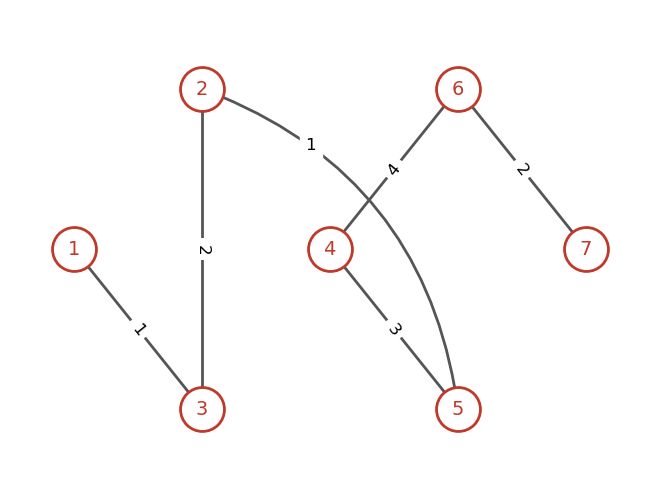

In [8]:
red.add_edge(6,7,weight=2)    #a la red le agregamos la conexión (6,7) y ademas el peso del arco
pesos = nx.get_edge_attributes(red, "weight") #volvemos a calcular el diccionario el cual extrae los conexiones y los pesos correspondientes a cada conexion
# En este paso ocupmos una curbatura para mostrarlo tal cual la red original, etonces dibujamos la red en dos pasos:
#Primero los arcos que no ocupan curva
rectos = []                       # Generamos lista vacia para los arcos que no ocupan curva
for arco in red.edges:            # En la red vamos a recorrer cada arco
    if set(arco) != {2, 5}:       # si no es el arco 5–2
        rectos.append(arco)       # lo agrega a la lista
nx.draw(red, pos,       #Dibujamos primero los arcos sin curvatura
        edgelist=rectos,          # Estos arcos los extraemos de la lista rectos
        with_labels=True,         #Nombre de cada nodo
        node_color="white",       #Relleno del nodo
        edgecolors="#C0392B",     #Color del contorno
        linewidths=2,             #Grosor del contorno
        font_color="#C0392B",     #Color del numero dentro del nodo
        node_size=1000,           #Tamaño del nodo
        font_size=14,             #Tamaño del numero dentro del nodo
        edge_color="#555555",     #Color del arco
        width=2)                  #Grosor del arco

#Ahora dibujamos el arco que ocupa curvatura
nx.draw_networkx_edges(red, pos,               
                       edgelist=[(5, 2)],    #Le decimos que dibuje unicamente el arco curvo
                       connectionstyle="arc3,rad=0.3",   # La curvatura
                       arrows=True, arrowstyle="-",      # Jypeter solo curva arcos con flecha, al poner - le quitamos la punta de la flecha
                       edge_color="#555555",             #Color del arco
                       width=2,                          # Grosor del arco
                       node_size=1000)                   #Tamaño del nodo

# Pesos de los arcos rectos
pesos_rectos = {arco: p for arco, p in pesos.items() if set(arco) != {2, 5}} #Generamos una lista la cual extrae del diccionario pesos las conexiones(arco) y el peso (p) separandolos para guardarlos
#en la lista pero solo los arcos distintos a {2,5}
nx.draw_networkx_edge_labels(red, pos, edge_labels=pesos_rectos,
                             font_color="black", font_size=12)    #Dibuja los pesos de los arcos rectos

# Peso del arco curvo, colocado de manera especifica
plt.text(1.85, 0.65, "1", color="black", fontsize=12,
         ha="center", va="center", backgroundcolor="white")
plt.xlim(-0.5, 4.5)
plt.ylim(-1.5, 1.5)   #Ponemos el encuadre de siempre
plt.show()

<p style="font-family: Verdana; color: #333333">
    <b style="color: #1F3A5F">Resultado:</b> el árbol de mínima expansión está formado por 6 arcos, $(4, 5)$, $(5, 2)$, $(2, 3)$, $(3, 1)$, $(4, 6)$ y $(6, 7)$, con un peso total de $3 + 1 + 2 + 1 + 4 + 2 = 13$.
</p>

<h2 style="color: #1F3A5F; font-family: Georgia"><span style="color: orange">b.</span>Problema de la ruta más corta</h2>

<p style="font-family: Verdana; color: #333333">
    <b style="color: #2A9D8F">Objetivo:</b> encontrar el camino que conecta el nodo inicial con el nodo final recorriendo la <b>menor distancia total</b>. Para lograrlo, en cada iteración se encuentra el siguiente nodo más cercano al origen, hasta que el siguiente nodo más cercano sea el destino.
</p>

<p style="font-family: Verdana; color: #333333">
    La red sobre la que vamos a trabajar es la siguiente:
</p>

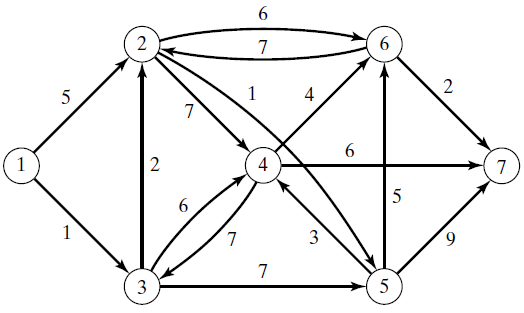

<p style="font-family: Verdana; color: #333333">
    <b style="color: #6A4C93">Definición:</b> un nodo <b>resuelto</b> es aquel cuya distancia mínima desde el origen ya se conoce. Los nodos cuya distancia mínima aún no se ha determinado se llaman <b>no resueltos</b>.
</p>

<p style="font-family: Verdana; color: #333333">
    En cada iteración vamos a llenar una tabla con las siguientes columnas:
</p>

<table style="font-family: Verdana; color: #333333; border-collapse: collapse; text-align: center">
  <tr style="background-color: #1F3A5F; color: white">
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodos resueltos conectados directamente a nodos no resueltos</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodo no resuelto más cercano conectado</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia total involucrada</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$-ésimo nodo más cercano</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia mínima</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Última conexión</th>
  </tr>
</table>

<p style="font-family: Verdana; color: #333333">
    Cada iteración ocupa una filas de la tabla. En la primera iteración, el único nodo resuelto es el nodo inicial, así que va en la segunda columna; después se busca, entre los nodos conectados directamente a él, el que tenga el arco de menor distancia, y ese nodo pasa a ser resuelto.
</p>

<p style="font-family: Verdana; color: #333333">
    En las siguientes iteraciones ponemos especial atención en los nodos resueltos que están conectados directamente a nodos no resueltos. Para cada uno de ellos se identifica su nodo no resuelto más cercano y se calcula la <b>distancia total desde el origen</b>: la distancia mínima del nodo resuelto más el peso del arco. Entre todos los candidatos se elige el de menor distancia total, y ese nodo pasa a ser resuelto. El algoritmo termina cuando el siguiente nodo más cercano es el nodo destino.
</p>

<p style="font-family: Verdana; color: #333333">
    Con la idea del algoritmo explicada, vamos a resolver el ejercicio.
</p>

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 1</h3>

<p style="font-family: Verdana; color: #333333">
    Como es la primera iteración, la tabla se llena de la siguiente manera:
</p>

<ol style="font-family: Verdana; color: #333333">
    <li><b>$n$:</b> como es la primera iteración, $n = 1$.</li>
    <li><b>Nodos resueltos conectados directamente a nodos no resueltos:</b> ponemos el nodo inicial, es decir, el 1.</li>
    <li><b>Nodo no resuelto más cercano conectado:</b> el nodo 1 tiene dos opciones, el 2 o el 3. Hay que escoger el que tenga el arco de menor peso, que en este caso es el 3.</li>
    <li><b>Distancia total involucrada:</b> es la suma de los arcos desde el origen hasta el nodo que estamos conectando. Como solo llevamos un arco, la suma corresponde a su peso, que es 1.</li>
    <li><b>$n$-ésimo nodo más cercano:</b> ponemos el nodo que conectamos, el 3.</li>
    <li><b>Distancia mínima:</b> la distancia total del origen al nodo 3, que es 1.</li>
    <li><b>Última conexión:</b> ponemos $1 \to 3$, ya que conectamos el nodo 1 con el nodo 3.</li>
</ol>

<table style="font-family: Verdana; color: #333333; border-collapse: collapse; text-align: center">
  <tr style="background-color: #1F3A5F; color: white">
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodos resueltos conectados directamente a nodos no resueltos</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodo no resuelto más cercano conectado</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia total involucrada</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$-ésimo nodo más cercano</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia mínima</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Última conexión</th>
  </tr>
  <tr style="background-color: #FDEBD0">
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 \to 3$</td>
  </tr>
</table>

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 2</h3>

<p style="font-family: Verdana; color: #333333">
    La idea para esta y las siguientes iteraciones es revisar, desde los nodos que ya están resueltos, qué camino conviene tomar para que la distancia total desde el origen sea la más pequeña. Veámoslo con el ejemplo:
</p>

<ol style="font-family: Verdana; color: #333333">
    <li><b>$n$:</b> como es la segunda iteración, $n = 2$.</li>
    <li><b>Nodos resueltos conectados directamente a nodos no resueltos:</b> ahora hay dos elementos, los nodos 1 y 3, ya que ambos están resueltos y están conectados directamente a nodos no resueltos.</li>
    <li><b>Nodo no resuelto más cercano conectado:</b> hay que escoger la conexión más conveniente de cada nodo. El nodo 1 solo está conectado directamente al nodo no resuelto 2. El nodo 3 está conectado directamente a tres nodos no resueltos: el 2 (peso 2), el 4 (peso 6) y el 5 (peso 7); el de menor peso es el 2. Por lo tanto, en esta columna va el 2 para ambos nodos.</li>
    <li><b>Distancia total involucrada:</b> aquí hay que separar en casos, uno por cada opción: $1 \to 2$ y $3 \to 2$, que en realidad es $1 \to 3 \to 2$. Para $1 \to 2$, la distancia desde el origen es 5. Para $3 \to 2$, la distancia total desde el origen es $1 + 2 = 3$. Cada distancia se escribe en la fila de su nodo resuelto, y se deja indicada la suma para que se vea la operación.</li>
    <li><b>$n$-ésimo nodo más cercano:</b> se escoge el que tenga la menor distancia total desde el origen, que es el nodo 2.</li>
    <li><b>Distancia mínima:</b> la distancia total del origen al nodo 2, que es 3.</li>
    <li><b>Última conexión:</b> $3 \to 2$.</li>
</ol>

<table style="font-family: Verdana; color: #333333; border-collapse: collapse; text-align: center">
  <tr style="background-color: #1F3A5F; color: white">
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodos resueltos conectados directamente a nodos no resueltos</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodo no resuelto más cercano conectado</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia total involucrada</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$-ésimo nodo más cercano</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia mínima</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Última conexión</th>
  </tr>

  <!-- Iteración 1 -->
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 \to 3$</td>
  </tr>

  <!-- Iteración 2 -->
  <tr style="background-color: #FDEBD0">
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 \to 2$</td>
  </tr>
  <tr style="background-color: #FDEBD0">
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 2 = 3$</td>
  </tr>
</table>

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 3</h3>

<p style="font-family: Verdana; color: #333333">
    Seguimos con la misma idea de la iteración pasada:
</p>

<ol style="font-family: Verdana; color: #333333">
    <li><b>$n$:</b> ahora $n = 3$.</li>
    <li><b>Nodos resueltos conectados directamente a nodos no resueltos:</b> ahora son el 2 y el 3. El nodo 1 ya no se considera, porque sus únicas conexiones son con el 2 y el 3, que ya están resueltos.</li>
    <li><b>Nodo no resuelto más cercano conectado:</b> analizamos las conexiones de cada nodo:
        <ul>
            <li>El nodo 2 tiene conexiones directas con el 4 (peso 7), el 6 (peso 6) y el 5 (peso 1); el de menor peso es el 5.</li>
            <li>El nodo 3 tiene conexiones directas con el 4 (peso 6) y el 5 (peso 7); el de menor peso es el 4.</li>
        </ul>
        Entonces, para el nodo 2 va el 5, y para el nodo 3 va el 4.
    </li>
    <li><b>Distancia total involucrada:</b> para el nodo 2 es $3 + 1 = 4$. El 3 es la distancia mínima para llegar al nodo 2, que podemos consultar en la tabla: buscamos el 2 en la columna "$n$-ésimo nodo más cercano" y vemos su distancia mínima. Aplicando la misma idea al nodo 3, su suma es $1 + 6 = 7$.</li>
    <li><b>$n$-ésimo nodo más cercano:</b> escogemos el de menor distancia total, que es el nodo 5.</li>
    <li><b>Distancia mínima:</b> la distancia total para llegar al nodo 5, que es 4.</li>
    <li><b>Última conexión:</b> $2 \to 5$.</li>
</ol>

<table style="font-family: Verdana; color: #333333; border-collapse: collapse; text-align: center">
  <tr style="background-color: #1F3A5F; color: white">
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodos resueltos conectados directamente a nodos no resueltos</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodo no resuelto más cercano conectado</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia total involucrada</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$-ésimo nodo más cercano</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia mínima</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Última conexión</th>
  </tr>

  <!-- Iteración 1 -->
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 \to 3$</td>
  </tr>

  <!-- Iteración 2 -->
  <tr>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 \to 2$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 2 = 3$</td>
  </tr>

  <!-- Iteración 3 -->
  <tr style="background-color: #FDEBD0">
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 + 1 = 4$</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">$2 \to 5$</td>
  </tr>
  <tr style="background-color: #FDEBD0">
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 6 = 7$</td>
  </tr>
</table>

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 4</h3>

<ol style="font-family: Verdana; color: #333333">
    <li><b>$n$:</b> ahora $n = 4$.</li>
    <li><b>Nodos resueltos conectados directamente a nodos no resueltos:</b> los nodos 2, 3 y 5.</li>
    <li><b>Nodo no resuelto más cercano conectado:</b>
        <ul>
            <li>El nodo 2 está conectado al 6 (peso 6) y al 4 (peso 7); el de menor peso es el 6.</li>
            <li>El nodo 3 está conectado únicamente al nodo 4 (peso 6).</li>
            <li>El nodo 5 está conectado al 7 (peso 9), al 4 (peso 3) y al 6 (peso 5); el de menor peso es el 4.</li>
        </ul>
    </li>
    <li><b>Distancia total involucrada:</b>
        <ul>
            <li>La distancia para llegar al nodo 2 es 3, y le sumamos la distancia del 2 al 6: $3 + 6 = 9$.</li>
            <li>La distancia para llegar al nodo 3 es 1, y del 3 al 4 es 6: $1 + 6 = 7$.</li>
            <li>La distancia para llegar al nodo 5 es 4, y del 5 al 4 es 3: $4 + 3 = 7$.</li>
        </ul>
    </li>
    <li><b>$n$-ésimo nodo más cercano:</b> el nodo más cercano es el 4. Sin embargo, hay dos caminos que llegan a él con la misma distancia, así que hay que considerar los dos.</li>
    <li><b>Distancia mínima:</b> 7.</li>
    <li><b>Última conexión:</b> como consideramos los dos caminos, las últimas conexiones son $3 \to 4$ y $5 \to 4$. Esto indica que puede haber más de una ruta más corta.</li>
</ol>

<table style="font-family: Verdana; color: #333333; border-collapse: collapse; text-align: center">
  <tr style="background-color: #1F3A5F; color: white">
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodos resueltos conectados directamente a nodos no resueltos</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodo no resuelto más cercano conectado</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia total involucrada</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$-ésimo nodo más cercano</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia mínima</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Última conexión</th>
  </tr>

  <!-- Iteración 1 -->
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 \to 3$</td>
  </tr>

  <!-- Iteración 2 -->
  <tr>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 \to 2$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 2 = 3$</td>
  </tr>

  <!-- Iteración 3 -->
  <tr>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 + 1 = 4$</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">$2 \to 5$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 6 = 7$</td>
  </tr>

  <!-- Iteración 4 -->
  <tr style="background-color: #FDEBD0">
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 + 6 = 9$</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">7</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 \to 4$<br>$5 \to 4$</td>
  </tr>
  <tr style="background-color: #FDEBD0">
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 6 = 7$</td>
  </tr>
  <tr style="background-color: #FDEBD0">
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$4 + 3 = 7$</td>
  </tr>
</table>

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 5</h3>

<ol style="font-family: Verdana; color: #333333">
    <li><b>$n$:</b> ahora $n = 5$.</li>
    <li><b>Nodos resueltos conectados directamente a nodos no resueltos:</b> los nodos que aún tienen conexión con nodos no resueltos son el 2, el 4 y el 5.</li>
    <li><b>Nodo no resuelto más cercano conectado:</b>
        <ul>
            <li>Como el 4 ya está resuelto, el nodo 2 ahora solo está conectado al 6 (peso 6).</li>
            <li>El nodo 4 tiene dos opciones: el 6 (peso 4) y el 7 (peso 6); el de menor peso es el 6.</li>
            <li>El nodo 5 también tiene dos opciones: el 6 (peso 5) y el 7 (peso 9); el de menor peso es el 6.</li>
        </ul>
    </li>
    <li><b>Distancia total involucrada:</b>
        <ul>
            <li>La distancia para llegar al nodo 2 es 3, y del 2 al 6 es 6: $3 + 6 = 9$.</li>
            <li>La distancia para llegar al nodo 4 es 7, y del 4 al 6 es 4: $7 + 4 = 11$.</li>
            <li>La distancia para llegar al nodo 5 es 4, y del 5 al 6 es 5: $4 + 5 = 9$.</li>
        </ul>
    </li>
    <li><b>$n$-ésimo nodo más cercano:</b> el nodo más cercano es el 6. Igual que en la iteración anterior, hay dos caminos que llegan a él con la misma distancia mínima, así que hay que considerar los dos.</li>
    <li><b>Distancia mínima:</b> 9.</li>
    <li><b>Última conexión:</b> $2 \to 6$ y $5 \to 6$.</li>
</ol>

<table style="font-family: Verdana; color: #333333; border-collapse: collapse; text-align: center">
  <tr style="background-color: #1F3A5F; color: white">
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodos resueltos conectados directamente a nodos no resueltos</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodo no resuelto más cercano conectado</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia total involucrada</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$-ésimo nodo más cercano</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia mínima</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Última conexión</th>
  </tr>

  <!-- Iteración 1 -->
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 \to 3$</td>
  </tr>

  <!-- Iteración 2 -->
  <tr>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 \to 2$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 2 = 3$</td>
  </tr>

  <!-- Iteración 3 -->
  <tr>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 + 1 = 4$</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">$2 \to 5$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 6 = 7$</td>
  </tr>

  <!-- Iteración 4 -->
  <tr>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 + 6 = 9$</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">7</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 \to 4$<br>$5 \to 4$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 6 = 7$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$4 + 3 = 7$</td>
  </tr>

  <!-- Iteración 5 -->
  <tr style="background-color: #FDEBD0">
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 + 6 = 9$</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">9</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">$2 \to 6$<br>$5 \to 6$</td>
  </tr>
  <tr style="background-color: #FDEBD0">
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$7 + 4 = 11$</td>
  </tr>
  <tr style="background-color: #FDEBD0">
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$4 + 5 = 9$</td>
  </tr>
</table>

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 6</h3>

<ol style="font-family: Verdana; color: #333333">
    <li><b>$n$:</b> ahora $n = 6$.</li>
    <li><b>Nodos resueltos conectados directamente a nodos no resueltos:</b> los nodos que aún están conectados al único nodo no resuelto son el 4, el 5 y el 6.</li>
    <li><b>Nodo no resuelto más cercano conectado:</b> para todos es el nodo 7.</li>
    <li><b>Distancia total involucrada:</b>
        <ul>
            <li>La distancia para llegar al nodo 4 es 7, y del 4 al 7 es 6: $7 + 6 = 13$.</li>
            <li>La distancia para llegar al nodo 5 es 4, y del 5 al 7 es 9: $4 + 9 = 13$.</li>
            <li>La distancia para llegar al nodo 6 es 9, y del 6 al 7 es 2: $9 + 2 = 11$.</li>
        </ul>
    </li>
    <li><b>$n$-ésimo nodo más cercano:</b> el nodo 7.</li>
    <li><b>Distancia mínima:</b> 11.</li>
    <li><b>Última conexión:</b> $6 \to 7$.</li>
</ol>

<p style="font-family: Verdana; color: #333333">
    Como llegamos al nodo destino, el algoritmo termina. Para concluir, hay que observar la tabla.
</p>

<table style="font-family: Verdana; color: #333333; border-collapse: collapse; text-align: center">
  <tr style="background-color: #1F3A5F; color: white">
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodos resueltos conectados directamente a nodos no resueltos</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Nodo no resuelto más cercano conectado</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia total involucrada</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">$n$-ésimo nodo más cercano</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Distancia mínima</th>
    <th style="padding: 6px 10px; border: 1px solid #CCCCCC">Última conexión</th>
  </tr>

  <!-- Iteración 1 -->
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 \to 3$</td>
  </tr>

  <!-- Iteración 2 -->
  <tr>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">1</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 \to 2$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 2 = 3$</td>
  </tr>

  <!-- Iteración 3 -->
  <tr>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 + 1 = 4$</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td rowspan="2" style="padding: 6px 10px; border: 1px solid #CCCCCC">$2 \to 5$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 6 = 7$</td>
  </tr>

  <!-- Iteración 4 -->
  <tr>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 + 6 = 9$</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">7</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 \to 4$<br>$5 \to 4$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">3</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$1 + 6 = 7$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$4 + 3 = 7$</td>
  </tr>

  <!-- Iteración 5 -->
  <tr>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">2</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$3 + 6 = 9$</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">9</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">$2 \to 6$<br>$5 \to 6$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$7 + 4 = 11$</td>
  </tr>
  <tr>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$4 + 5 = 9$</td>
  </tr>

  <!-- Iteración 6 -->
  <tr style="background-color: #FDEBD0">
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">4</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">7</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$7 + 6 = 13$</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">7</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">11</td>
    <td rowspan="3" style="padding: 6px 10px; border: 1px solid #CCCCCC">$6 \to 7$</td>
  </tr>
  <tr style="background-color: #FDEBD0">
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">5</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">7</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$4 + 9 = 13$</td>
  </tr>
  <tr style="background-color: #FDEBD0">
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">6</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">7</td>
    <td style="padding: 6px 10px; border: 1px solid #CCCCCC">$9 + 2 = 11$</td>
  </tr>
</table>

<h3 style="font-family: Georgia; color: #1F3A5F">¿Cómo concluimos mirando la tabla?</h3>

<p style="font-family: Verdana; color: #333333">
    Hay que observar la tabla, en particular la columna "Última conexión", y recorrerla de atrás hacia adelante. Por simplicidad, escribiremos la ruta en sentido inverso con flechas $\leftarrow$:
</p>

<ol style="font-family: Verdana; color: #333333">
    <li>En la última iteración, la última conexión fue $6 \to 7$, así que empezamos con $7 \leftarrow 6$.</li>
    <li>Buscamos la iteración donde el 6 aparece como $n$-ésimo nodo más cercano (la iteración 5). Ahí hay dos opciones, $2 \to 6$ y $5 \to 6$. Por el momento tomamos una, $5 \to 6$, y después regresamos a la otra. Tenemos $7 \leftarrow 6 \leftarrow 5$.</li>
    <li>El 5 se resolvió en la iteración 3 y proviene del nodo 2: $7 \leftarrow 6 \leftarrow 5 \leftarrow 2$.</li>
    <li>El 2 proviene del nodo 3 (iteración 2), y el 3 proviene del nodo 1 (iteración 1): $7 \leftarrow 6 \leftarrow 5 \leftarrow 2 \leftarrow 3 \leftarrow 1$.</li>
    <li>Al invertirla obtenemos la primera ruta más corta: $1 \to 3 \to 2 \to 5 \to 6 \to 7$.</li>
    <li>Regresamos a la otra opción del paso 2: ahora tomamos $2 \to 6$ y tenemos $7 \leftarrow 6 \leftarrow 2$. Como ya vimos, al 2 se llega desde el 3 y al 3 desde el 1: $7 \leftarrow 6 \leftarrow 2 \leftarrow 3 \leftarrow 1$.</li>
    <li>Al invertirla obtenemos la segunda ruta más corta: $1 \to 3 \to 2 \to 6 \to 7$.</li>
</ol>

<p style="font-family: Verdana; color: #333333">
    El empate de la iteración 4 (en el nodo 4) no afecta el resultado, porque el nodo 4 no forma parte de ninguna de las rutas más cortas.
</p>

<p style="font-family: Verdana; color: #333333">
    <b style="color: #1F3A5F">Resultado:</b> existen dos rutas más cortas del nodo 1 al nodo 7, ambas con una distancia total de 11:
</p>

$$1 \to 3 \to 2 \to 5 \to 6 \to 7: \quad 1 + 2 + 1 + 5 + 2 = 11$$

$$1 \to 3 \to 2 \to 6 \to 7: \quad 1 + 2 + 6 + 2 = 11$$

<p style="font-family: Verdana; color: #333333">
    Ahora solo dibujamos estas dos rutas y listo
</p>

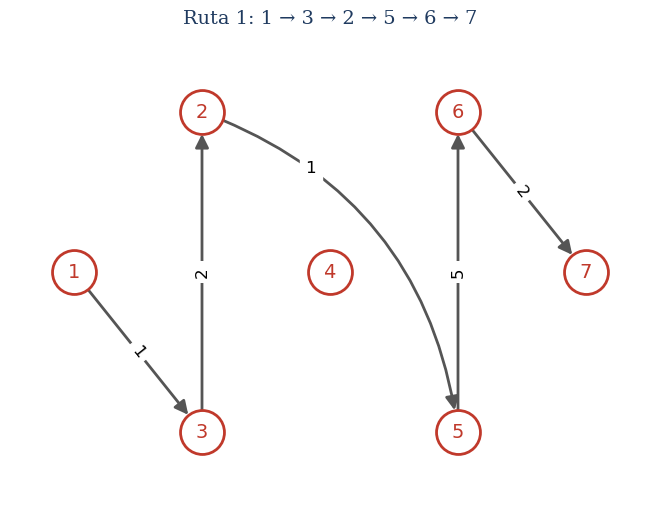

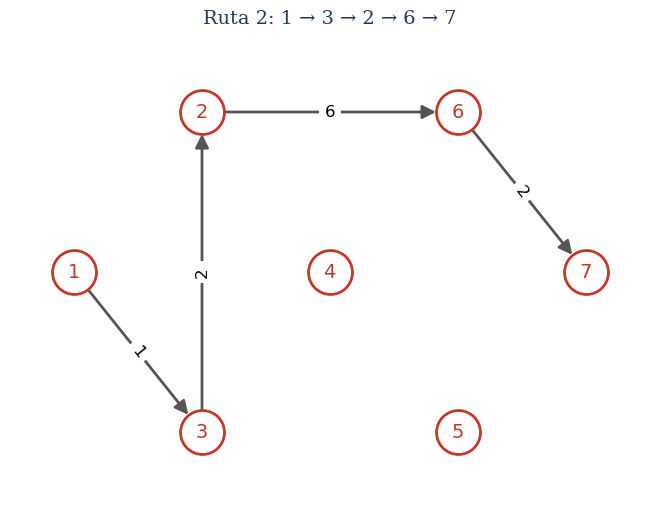

In [9]:
def dibujar_ruta(arcos, titulo): #Creamos la red
    ruta = nx.DiGraph()          #Le llamamos ruta a la red
    ruta.add_nodes_from(range(1, 8))        # Añadimos los nodos a la red vaica ruta
    ruta.add_weighted_edges_from(arcos)     # Ahora añadimos los arcos que ya definimos en codigo anterior

    # De igual manera separaremos el dibujo del arco que tiene curva
    curvo = (2, 5)
    rectos = [arco for arco in ruta.edges if arco != curvo]

    #Dibujamos los arcos rectos
    nx.draw(ruta, pos,
            edgelist=rectos,   #Sacamos los nodos de ruta, que estan en la posicion pos y con los pesos que se encuentran en la lista rectos
            with_labels=True,  #Mostramos el titulo del nodo
            node_color="white", #Ponemos el relleno del nodo en vlando
            edgecolors="#C0392B",  #Ponemos el color del controno del nodo
            linewidths=2,         #Ponemos el grosor del contorno del nodo
            font_color="#C0392B",  #Ponemos el color del numero dentro del nodo
            node_size=1000, #Ponemos el tamaño de los nodos
            font_size=14,    #Ponemos el tamaño del numero dentro del nodo
            edge_color="#555555",  #Ponemos el color de los arcos
            width=2,           #El grosor de los arcos
            arrows=True,       #Ponemos las flechas que nos dicen la direccion
            arrowstyle="-|>",       # El estilo de la flecha
            arrowsize=20)           # tamaño de la punta

    # Definimos la funcion de los arcos curvos
    if ruta.has_edge(2, 5):
        nx.draw_networkx_edges(ruta, pos,        #de igual manera que el anterior 
                               edgelist=[curvo],
                               connectionstyle="arc3,rad=-0.3",
                               arrows=True,
                               arrowstyle="-|>",
                               arrowsize=20,
                               edge_color="#555555",
                               width=2,
                               node_size=1000)
        plt.text(1.85, 0.65, "1", color="black", fontsize=12,
                 ha="center", va="center", backgroundcolor="white")

    # Pesos de los arcos rectos
    pesos = nx.get_edge_attributes(ruta, "weight")
    pesos_rectos = {arco: p for arco, p in pesos.items() if arco != curvo}
    nx.draw_networkx_edge_labels(ruta, pos, edge_labels=pesos_rectos,
                                 font_color="black", font_size=12)

    plt.title(titulo, color="#1F3A5F", fontsize=14, fontfamily="serif")
    plt.xlim(-0.5, 4.5)
    plt.ylim(-1.5, 1.5)
    plt.show()


# Dibujar cada ruta
dibujar_ruta([(1, 3, 1), (3, 2, 2), (2, 5, 1), (5, 6, 5), (6, 7, 2)],
             "Ruta 1: 1 → 3 → 2 → 5 → 6 → 7")

dibujar_ruta([(1, 3, 1), (3, 2, 2), (2, 6, 6), (6, 7, 2)],
             "Ruta 2: 1 → 3 → 2 → 6 → 7")

<h2 style="color: #1F3A5F; font-family: Georgia"><span style="color: orange">c.</span> Flujo Máximo</h2>

<p style="font-family: Verdana; color: #333333">
    <b style="color: #2A9D8F">Objetivo:</b> determinar dos cosas: el <b>flujo total máximo</b> que puede viajar a través de la red desde el nodo fuente hasta el nodo destino, y la <b>cantidad de flujo</b> que hay que mandar por cada arco.
</p>

<p style="font-family: Verdana; color: #333333">
    Esto lo resolveremos con el <b>algoritmo de trayectoria de aumento</b>. El primer paso consiste en preparar la red: si es dirigida, hay que transformarla en no dirigida, pero conservando sus capacidades en cada sentido.
</p>

<p style="font-family: Verdana; color: #333333">
    Por ejemplo, supongamos una red con dos nodos, el 1 y el 2, unidos por un solo arco con dirección del 1 al 2, por el que se pueden mandar como máximo $n$ unidades. Para convertirla en no dirigida, dibujamos una línea que une los dos nodos y anotamos la capacidad de cada sentido junto al nodo del que sale el flujo: cerca del nodo 1 ponemos $n$, porque del 1 al 2 se pueden mandar $n$ unidades, y cerca del nodo 2 ponemos 0, porque en esa dirección no se puede mandar nada. Es decir:
</p>

$$c_{12} = n \qquad c_{21} = 0$$

<p style="font-family: Verdana; color: #333333">
    donde $c_{ij}$ representa la capacidad de flujo del nodo $i$ al nodo $j$.
</p>

<p style="font-family: Verdana; color: #333333">
    Una vez que tenemos la red no dirigida con las capacidades correspondientes, la idea es encontrar en cada iteración una trayectoria de la fuente al destino por la cual mandar flujo. Este procedimiento lo explicaremos con más detalle mientras resolvemos el ejercicio.
</p>

<p style="font-family: Verdana; color: #333333">
    Ya que tenemos nuestra red no dirigida, trabajaremos sobre ella, tomando el nodo 1 como <b>fuente</b> y el nodo 5 como <b>destino</b>:
</p>

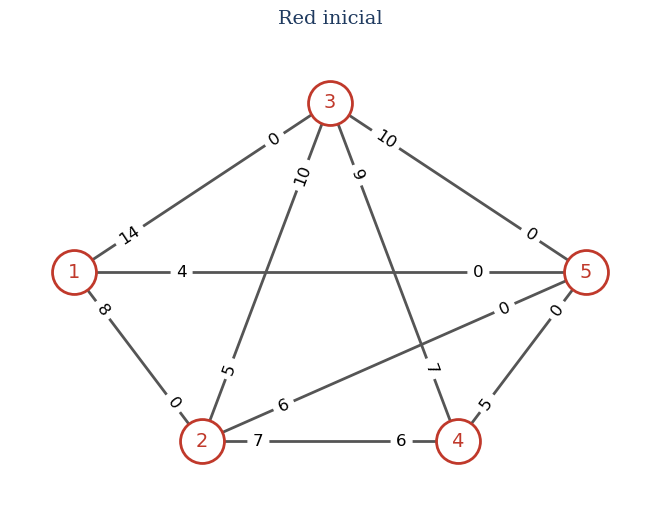

In [10]:
# Capacidades: cap[(i, j)] = lo que puede fluir de i hacia j
cap = {(1, 2): 8,  (2, 1): 0,
       (1, 3): 14, (3, 1): 0,
       (1, 5): 4,  (5, 1): 0,
       (2, 3): 5,  (3, 2): 10,
       (2, 4): 7,  (4, 2): 6,
       (2, 5): 6,  (5, 2): 0,
       (3, 4): 9,  (4, 3): 7,
       (3, 5): 10, (5, 3): 0,
       (4, 5): 5,  (5, 4): 0}

pos_flujo = {1: (0, 0), 2: (1, -1.2), 3: (2, 1.2), 4: (3, -1.2), 5: (4, 0)}

def dibujar_flujo(cap, titulo):
    red_flujo = nx.Graph()
    red_flujo.add_edges_from(cap.keys())

    nx.draw(red_flujo, pos_flujo,
            with_labels=True,
            node_color="white",
            edgecolors="#C0392B",
            linewidths=2,
            font_color="#C0392B",
            node_size=1000,
            font_size=14,
            edge_color="#555555",
            width=2)

    # Capacidad de u hacia v (cerca de u) y de v hacia u (cerca de v)
    cerca_u = {(u, v): cap[(u, v)] for u, v in red_flujo.edges}
    cerca_v = {(u, v): cap[(v, u)] for u, v in red_flujo.edges}

    nx.draw_networkx_edge_labels(red_flujo, pos_flujo, edge_labels=cerca_u,
                                 label_pos=0.2, font_color="black", font_size=12)
    nx.draw_networkx_edge_labels(red_flujo, pos_flujo, edge_labels=cerca_v,
                                 label_pos=0.8, font_color="black", font_size=12)

    plt.title(titulo, color="#1F3A5F", fontsize=14, fontfamily="serif")
    plt.xlim(-0.5, 4.5)
    plt.ylim(-1.7, 1.7)
    plt.show()

dibujar_flujo(cap, "Red inicial")

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 1</h3>

<ol style="font-family: Verdana; color: #333333">
    <li><b>Escoger una trayectoria de aumento:</b> desde el nodo 1, las opciones son el 2 (capacidad 8), el 3 (capacidad 14) y el 5 (capacidad 4); avanzamos al de mayor capacidad, el 3. Desde el nodo 3, las opciones son el 2 (10), el 4 (9) y el 5 (10); hay un empate entre el 2 y el 5, y escogemos el 5 porque es el destino. La trayectoria es $1 \to 3 \to 5$.</li>
    <li><b>Flujo de la trayectoria:</b> las capacidades de sus arcos son $\{14, 10\}$, y escogemos la mínima, 10. Esto significa que a través de la trayectoria $1 \to 3 \to 5$ solo podemos mandar como máximo 10 unidades.</li>
    <li><b>Actualizar las capacidades:</b> en cada arco de la trayectoria, la capacidad en el sentido del flujo disminuye en 10, y la del sentido contrario aumenta en 10:
        <ul>
            <li>Arco $(1, 3)$: del 1 al 3 quedan $14 - 10 = 4$, es decir, por ese arco aún podemos mandar 4 unidades. Del 3 al 1 la capacidad pasa a $0 + 10 = 10$.</li>
            <li>Arco $(3, 5)$: del 3 al 5 quedan $10 - 10 = 0$, es decir, por ese arco ya no podemos mandar nada. Del 5 al 3 la capacidad pasa a $0 + 10 = 10$.</li>
        </ul>
    </li>
</ol>

<p style="font-family: Verdana; color: #333333">
    Hay que recordar que estamos ingresando 10 unidades a la red por el nodo 1, y esas mismas 10 unidades están saliendo por el nodo 5. Dibujamos la red con las capacidades actualizadas y pasamos a la siguiente iteración:
</p>

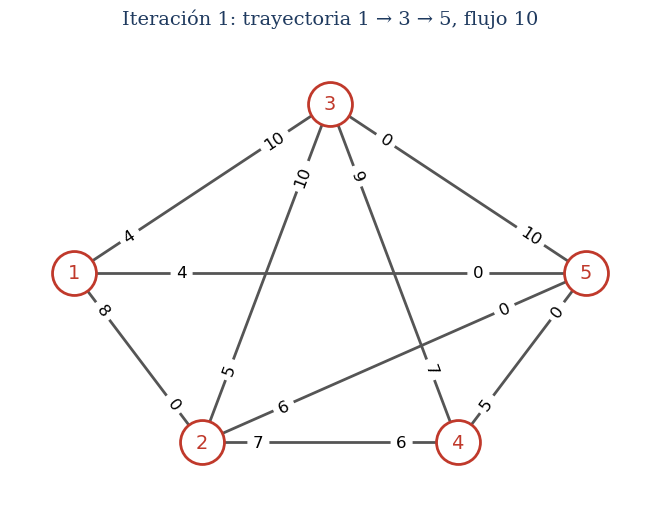

In [11]:
cap[(1, 3)] -= 10    # del 1 al 3: 14 - 10 = 4
cap[(3, 1)] += 10    # del 3 al 1: 0 + 10 = 10
cap[(3, 5)] -= 10    # del 3 al 5: 10 - 10 = 0
cap[(5, 3)] += 10    # del 5 al 3: 0 + 10 = 10

dibujar_flujo(cap, "Iteración 1: trayectoria 1 → 3 → 5, flujo 10")

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 2</h3>

<p style="font-family: Verdana; color: #333333">
    Seguimos con la misma idea, pero ahora trabajamos sobre la red con las capacidades actualizadas en la iteración 1.
</p>

<ol style="font-family: Verdana; color: #333333">
    <li><b>Escoger una trayectoria de aumento:</b>
        <ul>
            <li>Desde el nodo 1, las opciones son el 2 (capacidad 8), el 3 (4) y el 5 (4); avanzamos al 2.</li>
            <li>Desde el nodo 2, las opciones son el 3 (5), el 4 (7) y el 5 (6); avanzamos al 4.</li>
            <li>Desde el nodo 4, las opciones son el 3 (7) y el 5 (5); la mayor capacidad es hacia el 3. Sin embargo, desde el 3 no hay salida: la capacidad del 3 al 5 quedó en 0 en la iteración anterior, y sus demás vecinos ya forman parte de la trayectoria. Por lo tanto, <b>retrocedemos</b> al nodo 4, descartamos el 3 y avanzamos al 5.</li>
        </ul>
        La trayectoria es $1 \to 2 \to 4 \to 5$.
    </li>
    <li><b>Flujo de la trayectoria:</b> las capacidades de sus arcos son $\{8, 7, 5\}$, y la mínima es 5.</li>
    <li><b>Actualizar las capacidades:</b>
        <ul>
            <li>Arco $(1, 2)$: del 1 al 2 quedan $8 - 5 = 3$. Del 2 al 1 la capacidad pasa a $0 + 5 = 5$.</li>
            <li>Arco $(2, 4)$: del 2 al 4 quedan $7 - 5 = 2$. Del 4 al 2 la capacidad pasa a $6 + 5 = 11$.</li>
            <li>Arco $(4, 5)$: del 4 al 5 quedan $5 - 5 = 0$. Del 5 al 4 la capacidad pasa a $0 + 5 = 5$.</li>
        </ul>
    </li>
</ol>

<p style="font-family: Verdana; color: #333333">
    Hay que tener en mente que ahora llevamos un flujo total de $10 + 5 = 15$ unidades: 10 de la trayectoria anterior y 5 de esta. Dibujamos la red y pasamos a la siguiente iteración.
</p>

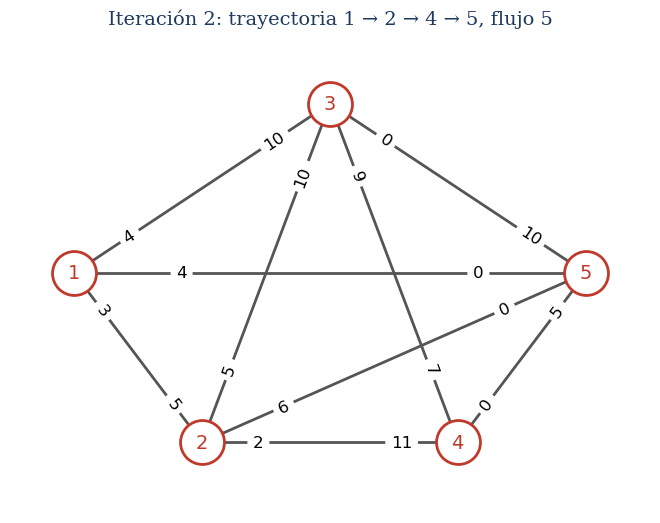

In [12]:
cap[(1, 2)] -= 5    # del 1 al 2: 8 - 5 = 3
cap[(2, 1)] += 5    # del 2 al 1: 0 + 5 = 5
cap[(2, 4)] -= 5    # del 2 al 4: 7 - 5 = 2
cap[(4, 2)] += 5    # del 4 al 2: 6 + 5 = 11
cap[(4, 5)] -= 5    # del 4 al 5: 5 - 5 = 0
cap[(5, 4)] += 5    # del 5 al 4: 0 + 5 = 5

dibujar_flujo(cap, "Iteración 2: trayectoria 1 → 2 → 4 → 5, flujo 5")

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 3</h3>

<ol style="font-family: Verdana; color: #333333">
    <li><b>Escoger una trayectoria de aumento:</b> desde el nodo 1, las opciones son el 2 (capacidad 3), el 3 (4) y el 5 (4). Hay un empate entre el 3 y el 5; igual que en la iteración 1, escogemos el 5 porque es el destino. La trayectoria es $1 \to 5$.</li>
    <li><b>Flujo de la trayectoria:</b> como solo hay un arco, lo máximo que podemos mandar es su capacidad, que es 4.</li>
    <li><b>Actualizar las capacidades:</b>
        <ul>
            <li>Arco $(1, 5)$: como mandamos toda su capacidad, del 1 al 5 quedan $4 - 4 = 0$. Del 5 al 1 la capacidad pasa a $0 + 4 = 4$.</li>
        </ul>
    </li>
</ol>

<p style="font-family: Verdana; color: #333333">
    El flujo total acumulado es ahora $15 + 4 = 19$ unidades. Dibujamos la red y pasamos a la siguiente iteración.
</p>

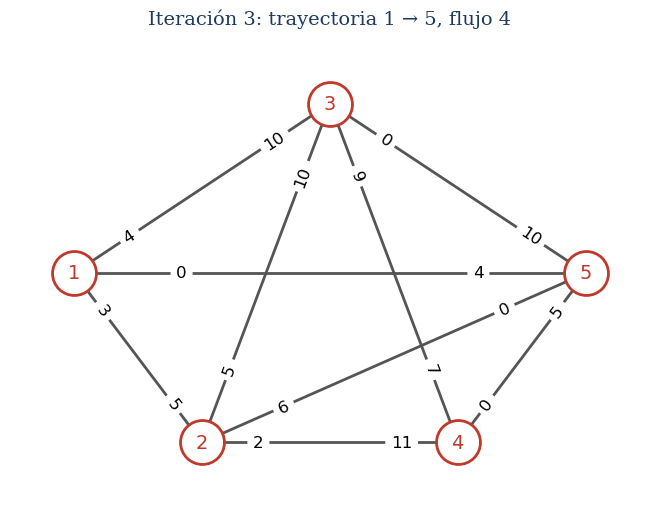

In [13]:
cap[(1, 5)] -= 4    # del 1 al 5: 4 - 4 = 0
cap[(5, 1)] += 4    # del 5 al 1: 0 + 4 = 4

dibujar_flujo(cap, "Iteración 3: trayectoria 1 → 5, flujo 4")

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 4</h3>

<ol style="font-family: Verdana; color: #333333">
    <li><b>Escoger una trayectoria de aumento:</b>
        <ul>
            <li>Desde el nodo 1 ya solo quedan dos opciones, porque la capacidad del 1 al 5 está en 0: el 2 (capacidad 3) y el 3 (4). Avanzamos al de mayor capacidad, el 3.</li>
            <li>Desde el nodo 3, las opciones son el 2 (10) y el 4 (9); avanzamos al 2.</li>
            <li>Desde el nodo 2, las opciones son el 4 (2) y el 5 (6); avanzamos al 5.</li>
        </ul>
        La trayectoria es $1 \to 3 \to 2 \to 5$.
    </li>
    <li><b>Flujo de la trayectoria:</b> las capacidades de sus arcos son $\{4, 10, 6\}$, y la mínima es 4.</li>
    <li><b>Actualizar las capacidades:</b>
        <ul>
            <li>Arco $(1, 3)$: del 1 al 3 quedan $4 - 4 = 0$. Del 3 al 1 la capacidad pasa a $10 + 4 = 14$.</li>
            <li>Arco $(3, 2)$: del 3 al 2 quedan $10 - 4 = 6$. Del 2 al 3 la capacidad pasa a $5 + 4 = 9$.</li>
            <li>Arco $(2, 5)$: del 2 al 5 quedan $6 - 4 = 2$. Del 5 al 2 la capacidad pasa a $0 + 4 = 4$.</li>
        </ul>
    </li>
</ol>

<p style="font-family: Verdana; color: #333333">
    El flujo total acumulado es ahora $19 + 4 = 23$ unidades: 19 de las iteraciones anteriores y 4 de esta. Dibujamos la red y pasamos a la siguiente iteración.
</p>

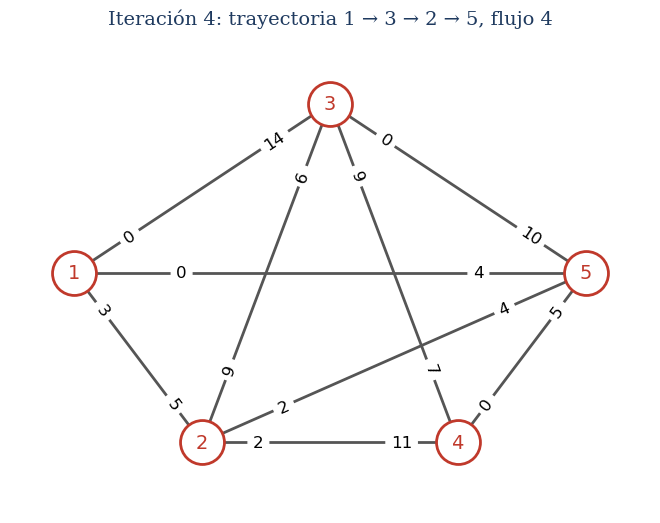

In [14]:
cap[(1, 3)] -= 4    # del 1 al 3: 4 - 4 = 0
cap[(3, 1)] += 4    # del 3 al 1: 10 + 4 = 14
cap[(3, 2)] -= 4    # del 3 al 2: 10 - 4 = 6
cap[(2, 3)] += 4    # del 2 al 3: 5 + 4 = 9
cap[(2, 5)] -= 4    # del 2 al 5: 6 - 4 = 2
cap[(5, 2)] += 4    # del 5 al 2: 0 + 4 = 4

dibujar_flujo(cap, "Iteración 4: trayectoria 1 → 3 → 2 → 5, flujo 4")

<h3 style="font-family: Georgia; color: #1F3A5F">Iteración 5</h3>

<ol style="font-family: Verdana; color: #333333">
    <li><b>Escoger una trayectoria de aumento:</b>
        <ul>
            <li>Desde el nodo 1 ya solo hay una opción, el 2 (capacidad 3).</li>
            <li>Desde el nodo 2, las opciones son el 3 (9), el 4 (2) y el 5 (2); avanzamos al 3.</li>
            <li>Desde el nodo 3, la única opción es el 4 (9), porque la capacidad del 3 al 5 está en 0; avanzamos al 4.</li>
            <li>Desde el nodo 4 no hay salida: la capacidad del 4 al 5 está en 0 y sus demás vecinos ya forman parte de la trayectoria. <b>Retrocedemos</b> al 3 y descartamos el 4.</li>
            <li>Desde el nodo 3 ya no queda ninguna opción, así que <b>retrocedemos</b> al 2 y descartamos el 3.</li>
            <li>Desde el nodo 2 quedan el 4 (2) y el 5 (2). Hay un empate, y escogemos el 5 porque es el destino.</li>
        </ul>
        La trayectoria es $1 \to 2 \to 5$.
    </li>
    <li><b>Flujo de la trayectoria:</b> las capacidades de sus arcos son $\{3, 2\}$, y la mínima es 2.</li>
    <li><b>Actualizar las capacidades:</b>
        <ul>
            <li>Arco $(1, 2)$: del 1 al 2 quedan $3 - 2 = 1$. Del 2 al 1 la capacidad pasa a $5 + 2 = 7$.</li>
            <li>Arco $(2, 5)$: del 2 al 5 quedan $2 - 2 = 0$. Del 5 al 2 la capacidad pasa a $4 + 2 = 6$.</li>
        </ul>
    </li>
</ol>

<p style="font-family: Verdana; color: #333333">
    El flujo total acumulado es ahora $23 + 2 = 25$ unidades: 23 de las iteraciones anteriores y 2 de esta. Dibujamos la red y pasamos a la siguiente iteración.
</p>

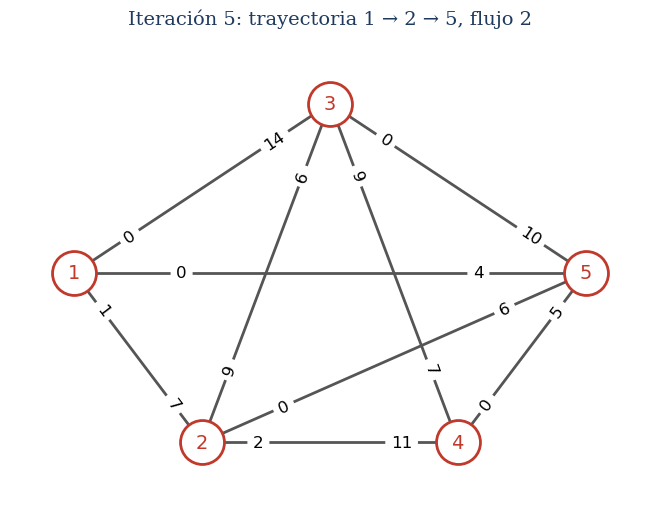

In [15]:
cap[(1, 2)] -= 2    # del 1 al 2: 3 - 2 = 1
cap[(2, 1)] += 2    # del 2 al 1: 5 + 2 = 7
cap[(2, 5)] -= 2    # del 2 al 5: 2 - 2 = 0
cap[(5, 2)] += 2    # del 5 al 2: 4 + 2 = 6

dibujar_flujo(cap, "Iteración 5: trayectoria 1 → 2 → 5, flujo 2")

<h3 style="font-family: Georgia; color: #1F3A5F">Conclusión</h3>

<p style="font-family: Verdana; color: #333333">
    Ya no existe ninguna trayectoria de aumento, porque todos los arcos que llegan al nodo destino tienen capacidad residual 0. Además, la capacidad original de esos arcos sumaba $4 + 6 + 10 + 5 = 25$, que es exactamente el flujo que hemos mandado, por lo que no es posible mandar más. Por lo tanto, el algoritmo termina.
</p>

<p style="font-family: Verdana; color: #333333">
    Para saber cuánto flujo pasa por cada arco y en qué dirección, comparamos la capacidad original con la capacidad residual final: si la capacidad de $i$ a $j$ disminuyó, la diferencia es el flujo que pasa de $i$ a $j$.
</p>

<ul style="font-family: Verdana; color: #333333">
    <li><b>Nodo 1:</b> manda 14 al 3, 4 al 5 y 7 al 2. En total salen $14 + 4 + 7 = 25$ unidades.</li>
    <li><b>Nodo 3:</b> recibe 14 y manda 10 al 5 y 4 al 2; al 4 no manda nada. Sale $10 + 4 = 14$, lo mismo que entra.</li>
    <li><b>Nodo 2:</b> recibe $7 + 4 = 11$ y manda 6 al 5 y 5 al 4; al 3 no manda nada. Sale $6 + 5 = 11$, lo mismo que entra.</li>
    <li><b>Nodo 4:</b> recibe 5 y manda 5 al 5; al 3 no manda nada.</li>
    <li><b>Nodo 5:</b> recibe $4 + 10 + 6 + 5 = 25$ unidades, las mismas que salieron del nodo 1.</li>
</ul>

<p style="font-family: Verdana; color: #333333">
    <b style="color: #1F3A5F">Resultado:</b> el flujo máximo del nodo 1 al nodo 5 es de <b>25 unidades</b>, distribuidas en los arcos como se muestra en la siguiente red:
</p>

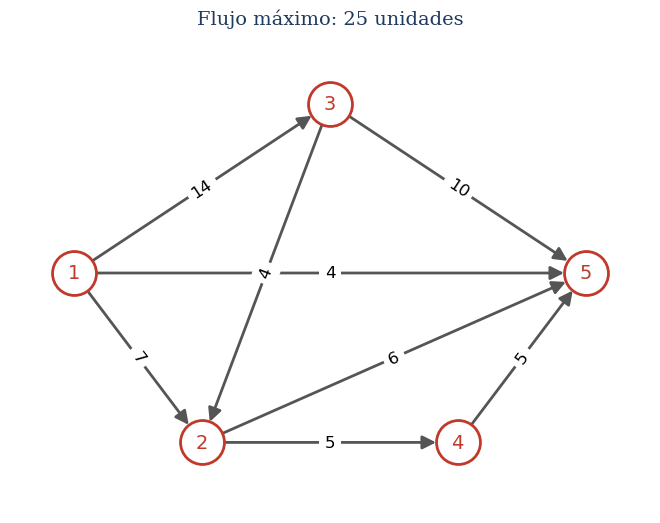

In [16]:
flujos = [(1, 3, 14), (1, 2, 7), (1, 5, 4),
          (3, 5, 10), (3, 2, 4),
          (2, 5, 6), (2, 4, 5),
          (4, 5, 5)]

red_final = nx.DiGraph()
red_final.add_weighted_edges_from(flujos)

nx.draw(red_final, pos_flujo,
        with_labels=True,
        node_color="white",
        edgecolors="#C0392B",
        linewidths=2,
        font_color="#C0392B",
        node_size=1000,
        font_size=14,
        edge_color="#555555",
        width=2,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=20)

etiquetas = nx.get_edge_attributes(red_final, "weight")
nx.draw_networkx_edge_labels(red_final, pos_flujo, edge_labels=etiquetas,
                             font_color="black", font_size=12)

plt.title("Flujo máximo: 25 unidades", color="#1F3A5F", fontsize=14, fontfamily="serif")
plt.xlim(-0.5, 4.5)
plt.ylim(-1.7, 1.7)
plt.show()

In [17]:
verif = nx.DiGraph()
for (i, j), c in {(1, 2): 8, (1, 3): 14, (1, 5): 4, (2, 3): 5, (3, 2): 10,
                  (2, 4): 7, (4, 2): 6, (2, 5): 6, (3, 4): 9, (4, 3): 7,
                  (3, 5): 10, (4, 5): 5}.items():
    verif.add_edge(i, j, capacity=c)

print(nx.maximum_flow_value(verif, 1, 5))

25
